In [131]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt
import warnings 
warnings.filterwarnings('ignore')

In [132]:
df  = pd.read_csv('insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [133]:
df.shape

(1338, 7)

In [134]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [135]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [136]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [137]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

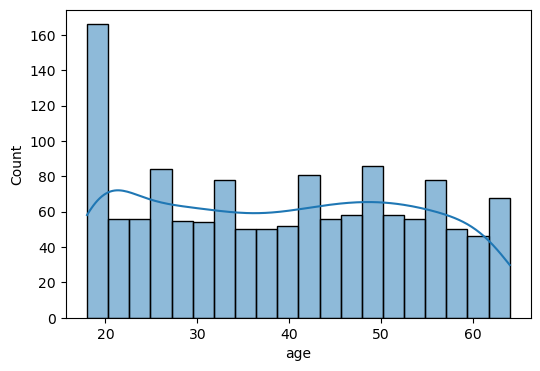

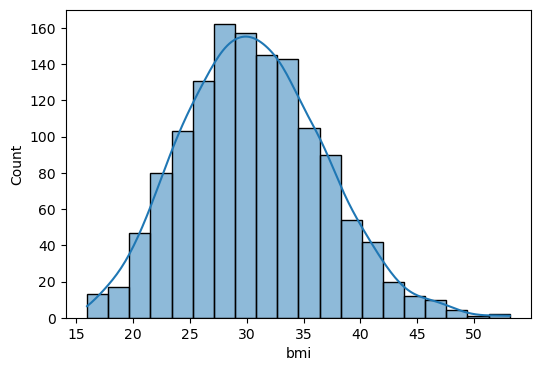

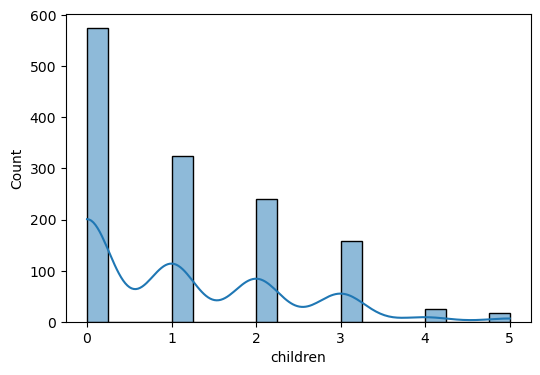

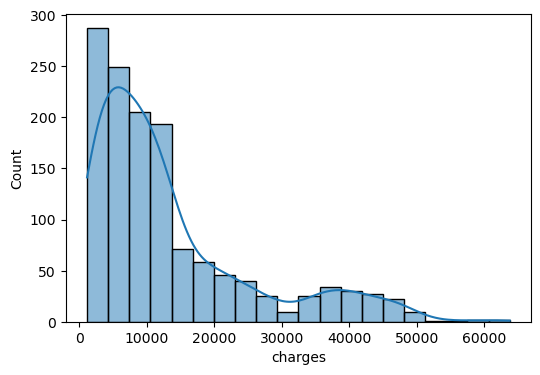

In [138]:
numeric_columns  = ['age' ,  'bmi' , 'children'   ,  'charges']
for col in numeric_columns:
    plt.figure(figsize=(6, 4))
    sns.histplot(df[col], kde=True, bins=20)


<Axes: xlabel='children', ylabel='count'>

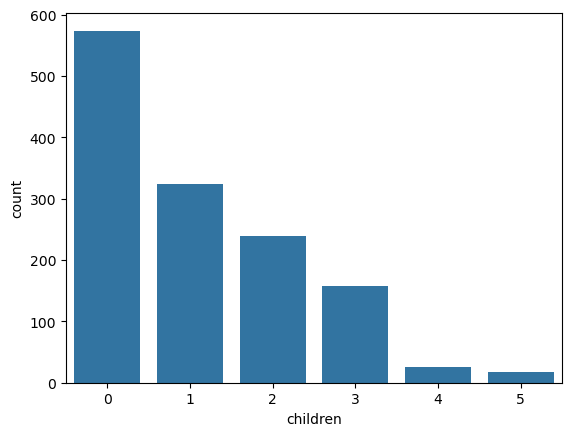

In [139]:
sns.countplot( x = df['children'])

<Axes: xlabel='sex', ylabel='count'>

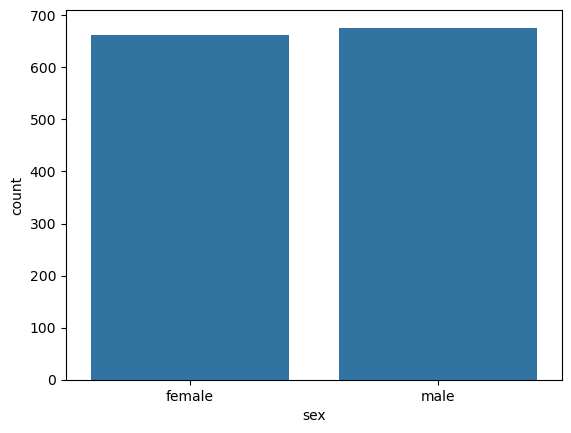

In [140]:
sns.countplot(x= df['sex'])

<Axes: xlabel='sex', ylabel='count'>

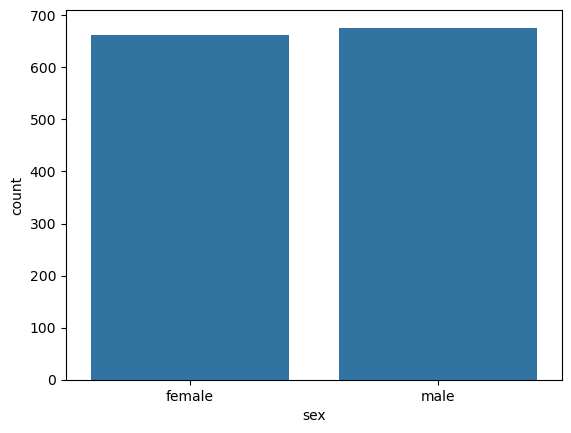

In [141]:
sns.countplot( x = df['sex'])

<Axes: xlabel='smoker', ylabel='count'>

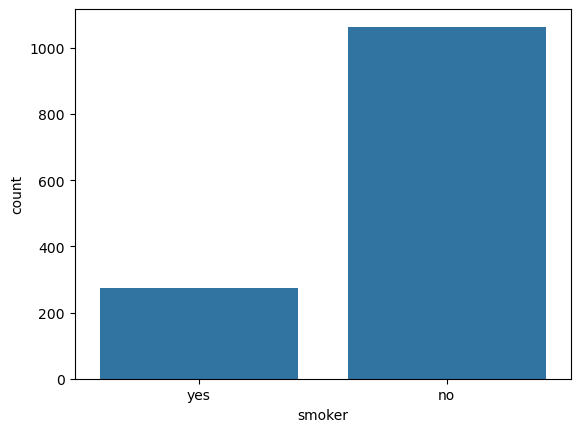

In [142]:
sns.countplot( x = df['smoker'])

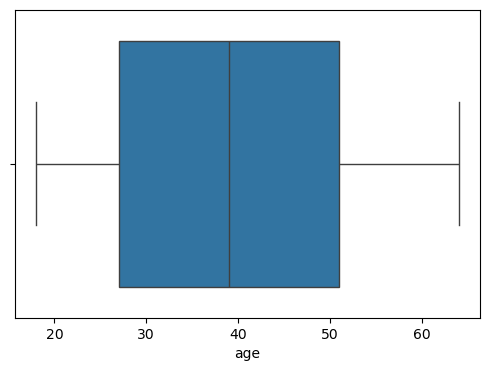

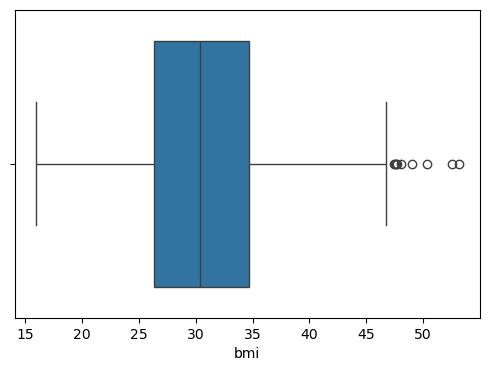

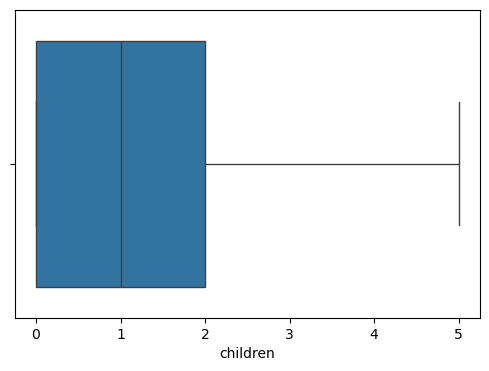

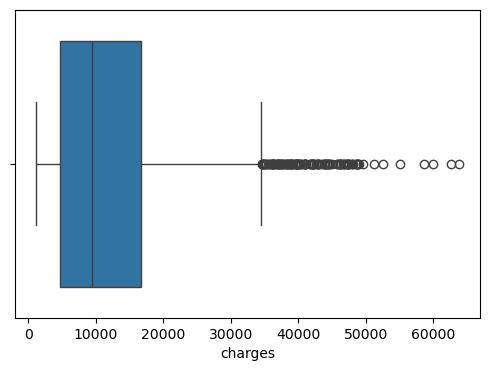

In [143]:
for col in numeric_columns:
    plt.figure(figsize = (6,4))
    sns.boxplot(x = df[col])

<Axes: >

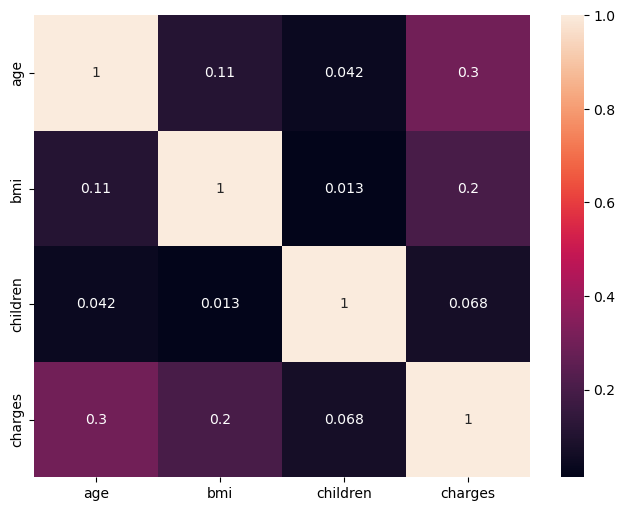

In [144]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot = True)

In [145]:
df_cleaned = df.copy()

In [146]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [147]:
df_cleaned.drop_duplicates(inplace = True)

In [148]:
df_cleaned.shape

(1337, 7)

In [149]:
df_cleaned.dtypes

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

In [150]:
df_cleaned['sex'].value_counts()

sex
male      675
female    662
Name: count, dtype: int64

### Mapping -> One Hot Encoding

In [151]:
df_cleaned['sex'] = df_cleaned['sex'].map({"male":0 , "female":1})

In [152]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,yes,southwest,16884.92400
1,18,0,33.770,1,no,southeast,1725.55230
2,28,0,33.000,3,no,southeast,4449.46200
3,33,0,22.705,0,no,northwest,21984.47061
4,32,0,28.880,0,no,northwest,3866.85520


In [153]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,yes,southwest,16884.92400
1,18,0,33.770,1,no,southeast,1725.55230
2,28,0,33.000,3,no,southeast,4449.46200
3,33,0,22.705,0,no,northwest,21984.47061
4,32,0,28.880,0,no,northwest,3866.85520


In [154]:
df_cleaned.rename(columns={
    'sex' : 'is_female',
    'smoker' : 'is_smoker'
}).head()

,age,is_female,bmi,children,is_smoker,region,charges
0,19,1,27.900,0,yes,southwest,16884.92400
1,18,0,33.770,1,no,southeast,1725.55230
2,28,0,33.000,3,no,southeast,4449.46200
3,33,0,22.705,0,no,northwest,21984.47061
4,32,0,28.880,0,no,northwest,3866.85520


In [155]:
df['region'].value_counts()

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

## Lable Encoding 

In [156]:
df_cleaned = pd.get_dummies(df_cleaned ,columns = ['region'], drop_first=True)

In [157]:
df_cleaned.head()
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1337 entries, 0 to 1337
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               1337 non-null   int64  
 1   sex               1337 non-null   int64  
 2   bmi               1337 non-null   float64
 3   children          1337 non-null   int64  
 4   smoker            1337 non-null   object 
 5   charges           1337 non-null   float64
 6   region_northwest  1337 non-null   bool   
 7   region_southeast  1337 non-null   bool   
 8   region_southwest  1337 non-null   bool   
dtypes: bool(3), float64(2), int64(3), object(1)
memory usage: 77.0+ KB


In [158]:
df_cleaned['smoker'] = df_cleaned['smoker'].map({
    'yes' : 1 ,
    'no'  : 0
})

In [159]:
df_bool = df_cleaned.select_dtypes(include='bool').columns
df_cleaned[df_bool] = df_cleaned[df_bool].astype(int)

In [160]:
df_float = df_cleaned.select_dtypes(include='float').columns
df_cleaned[df_float] = df_cleaned[df_float].astype(int)

In [161]:
df_cleaned.head()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27,0,1,16884,0,0,1
1,18,0,33,1,0,1725,0,1,0
2,28,0,33,3,0,4449,0,1,0
3,33,0,22,0,0,21984,1,0,0
4,32,0,28,0,0,3866,1,0,0


<Axes: xlabel='bmi', ylabel='Count'>

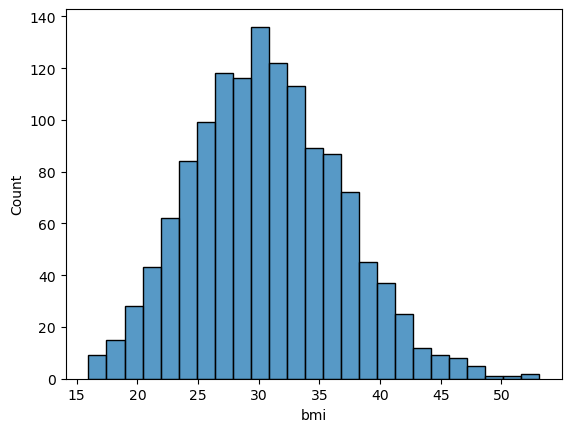

In [162]:
sns.histplot(df['bmi'])

In [165]:
df_cleaned['bmi_category'] = pd.cut(
    df_cleaned['bmi'],
    bins=[0,18.5,24.9,float('inf')],
    labels=['underweight','normal','overweight']
)

In [166]:
df_cleaned = pd.get_dummies(df_cleaned,columns = ['bmi_category'],drop_first=True)

In [168]:
df_cleaned.head()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_normal,bmi_category_overweight
0,19,1,27,0,1,16884,0,0,1,0,1
1,18,0,33,1,0,1725,0,1,0,0,1
2,28,0,33,3,0,4449,0,1,0,0,1
3,33,0,22,0,0,21984,1,0,0,1,0
4,32,0,28,0,0,3866,1,0,0,0,1


In [169]:
df_cleaned.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'charges',
       'region_northwest', 'region_southeast', 'region_southwest',
       'bmi_category_normal', 'bmi_category_overweight'],
      dtype='object')

In [170]:
from sklearn.preprocessing import StandardScaler
cols = ['age' , 'bmi' , 'children']
scaler = StandardScaler()

df_cleaned[cols] = scaler.fit_transform(df_cleaned[cols])

In [171]:
df_cleaned.head()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_normal,bmi_category_overweight
0,-1.440418,1,-0.517949,-0.909234,1,16884,0,0,1,0,1
1,-1.511647,0,0.462463,-0.079442,0,1725,0,1,0,0,1
2,-0.799350,0,0.462463,1.580143,0,4449,0,1,0,0,1
3,-0.443201,0,-1.334960,-0.909234,0,21984,1,0,0,1,0
4,-0.514431,0,-0.354547,-0.909234,0,3866,1,0,0,0,1


In [179]:
from scipy.stats import pearsonr

selected_feature = [
    'age','bmi','children','sex','smoker','charges',
    'region_northwest', 'region_southwest', 'region_southeast',
    'bmi_category_normal' , 'bmi_category_overweight' , ]

correlation = { 
        feature:pearsonr(df_cleaned[feature],df_cleaned['charges'])[0]
        for feature in selected_feature 
    }
correlation_df = pd.DataFrame(list(correlation.items()),columns=['Feature', 'Pearson Correlation'])
print(correlation_df)

                    Feature  Pearson Correlation
0                       age             0.298309
1                       bmi             0.196236
2                  children             0.067390
3                       sex            -0.058046
4                    smoker             0.787234
5                   charges             1.000000
6          region_northwest            -0.038695
7          region_southwest            -0.043637
8          region_southeast             0.073577
9       bmi_category_normal            -0.104042
10  bmi_category_overweight             0.117260


In [194]:
from scipy.stats import chi2_contingency
import pandas as pd 
alpha = 0.5
df_cleaned['charges_bin'] = pd.qcut(df_cleaned['charges'], q = 4, labels =False)
chi2_results = {}

cat_features = ['age','bmi','children','sex','smoker','charges',
    'region_northwest', 'region_southwest', 'region_southeast',
    'bmi_category_normal' , 'bmi_category_overweight' ]

for col in cat_features:
    contigency = pd.crosstab(df_cleaned[col],df_cleaned['charges_bin'])
    chi2_stat,p_val,_,_ = chi2_contingency(contigency)
    decision = 'Reject Null (keep Feature)' if p_val < alpha else 'accept null (drop feature)'
    
    chi2_results[col] = {
    'chi2_statistic': chi2_stat,
    'p_value' : p_val,
    'Decision' : decision
    }

In [195]:
chi2_df = pd.DataFrame(chi2_results).T
chi2_df = chi2_df.sort_values(by='p_value')
chi2_df

,chi2_statistic,p_value,Decision
age,1509.13025,0.0,Reject Null (keep Feature)
smoker,848.219178,0.0,Reject Null (keep Feature)
children,138.659313,0.0,Reject Null (keep Feature)
region_southeast,15.998167,0.001135,Reject Null (keep Feature)
sex,10.258784,0.01649,Reject Null (keep Feature)
bmi,144.758888,0.017278,Reject Null (keep Feature)
charges,4011.0,0.033723,Reject Null (keep Feature)
bmi_category_overweight,5.904983,0.116326,Reject Null (keep Feature)
region_southwest,5.091893,0.165191,Reject Null (keep Feature)
bmi_category_normal,3.708088,0.29476,Reject Null (keep Feature)
